### Setup & imports

In [2]:
import numpy as np
from DAS import DAS
import Utilities  # helpers

In [20]:
# Adjust these to your repo layout
root_path = "PoroTomo_DAS"
# "PoroTomo_iDAS16043_160314104318.h5" partially visible
# "PoroTomo_iDAS16043_160314073318.h5" invisible
test_file = "PoroTomo_iDAS16043_160314104148.h5"  # visible
file = f"{root_path}/{test_file}"
file

'PoroTomo_DAS/PoroTomo_iDAS16043_160314104148.h5'

### Load with the Silixa reader

In [31]:
# vendor is case-insensitive: "Silixa" or "silixa" both work
das = DAS(file, vendor="silixa")  # -> data in shape [channels, time]
print("Data shape [channels, time]:", das.data.shape)

# quick metadata peek
for k in ["vendor","dx","fs","dt","start_time_iso","part_start_time_dt","part_end_time_dt","raw_dtype","raw_shape"]:
    print(f"{k:20s}:", das.meta.get(k))

Data shape [channels, time]: (8721, 30000)
vendor              : Silixa
dx                  : 1.021
fs                  : 1000.0
dt                  : 0.001
start_time_iso      : 2016-03-14T10:41:48.862432+00:00
part_start_time_dt  : 2016-03-14 10:41:48.862432+00:00
part_end_time_dt    : 2016-03-14 10:42:18.861432+00:00
raw_dtype           : float32
raw_shape           : (30000, 8721)


In [23]:
das.data

array([[-9.4949482e-03, -8.1527531e-03, -1.0877961e-03, ...,
         1.4812762e-03,  9.6136786e-04,  1.9871839e-04],
       [-9.1648027e-03, -7.4133659e-03, -8.7602943e-04, ...,
         8.7321980e-04,  7.1835076e-04,  1.5763323e-04],
       [-6.3059032e-03, -4.3202080e-03, -3.6240890e-04, ...,
         1.1490943e-03,  6.9939508e-04,  1.4007796e-04],
       ...,
       [ 1.5505809e-01,  1.1718868e-01,  1.7269258e-01, ...,
        -2.6984593e-01, -1.2852371e-01, -2.2994524e-02],
       [-1.0720694e-02, -4.6897553e-02,  2.7370086e-01, ...,
        -3.0836061e-01, -1.3826548e-01, -2.4042813e-02],
       [ 4.3748271e-02,  4.9435545e-02,  2.9755378e-01, ...,
        -4.0392846e-01, -1.9346392e-01, -3.5368323e-02]], dtype=float32)

### Fast "just-plot-it"

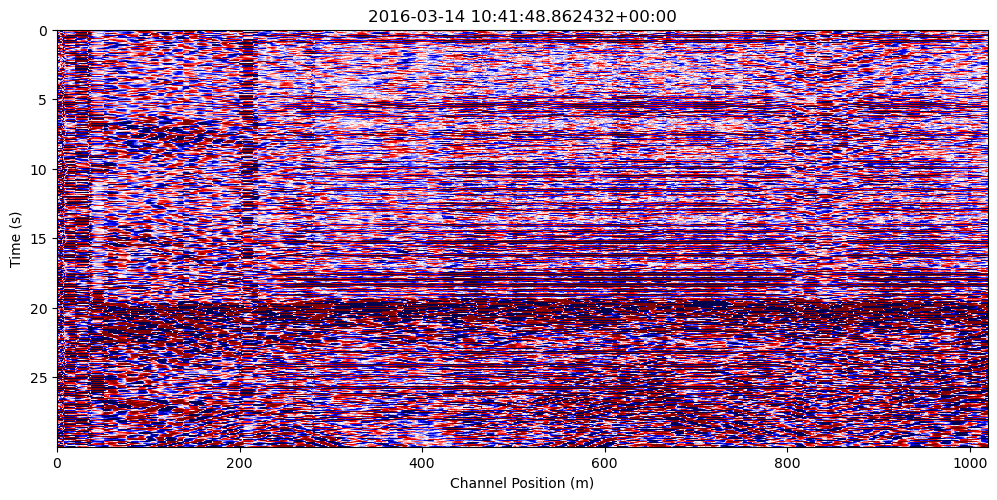

In [30]:
das.plot()

### Plot a time window and a single channel

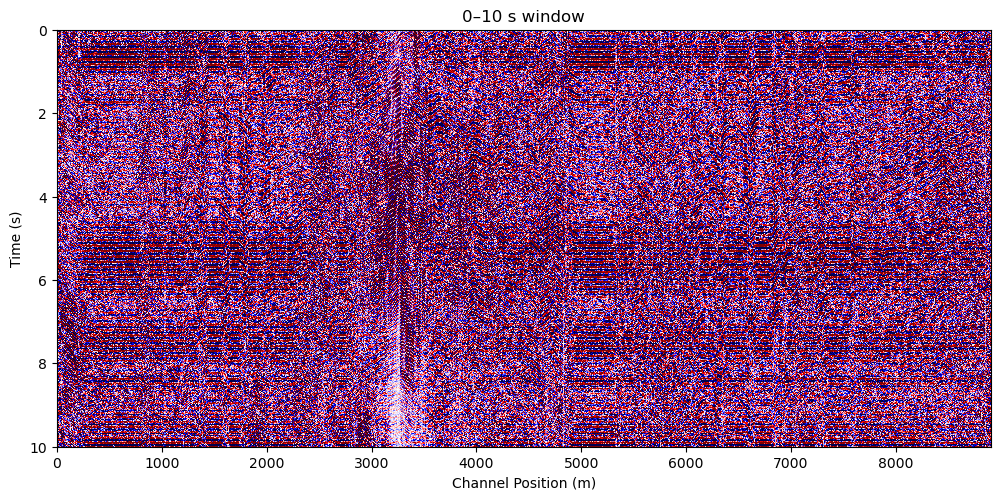

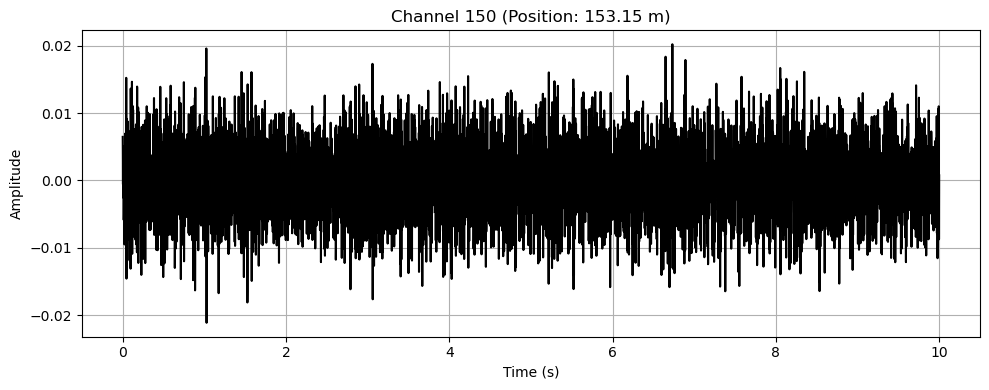

In [32]:
# windowed heatmap
das.plot(start_time=0.0, end_time=10.0, title="0–10 s window")

# single-channel trace (e.g., channel 150)
das.plot_single(ch=150, start_time=0.0, end_time=10.0)

### Preprocessing

In [33]:
from preprocessing import (
    detrend_then_bandpass, fk_filter, curvelet_like_denoise
)

x  = das.data            # [channels, time]
dx = das.meta["dx"]      # meters
dt = das.meta["dt"]      # seconds
fs = das.meta["fs"]      # Hz

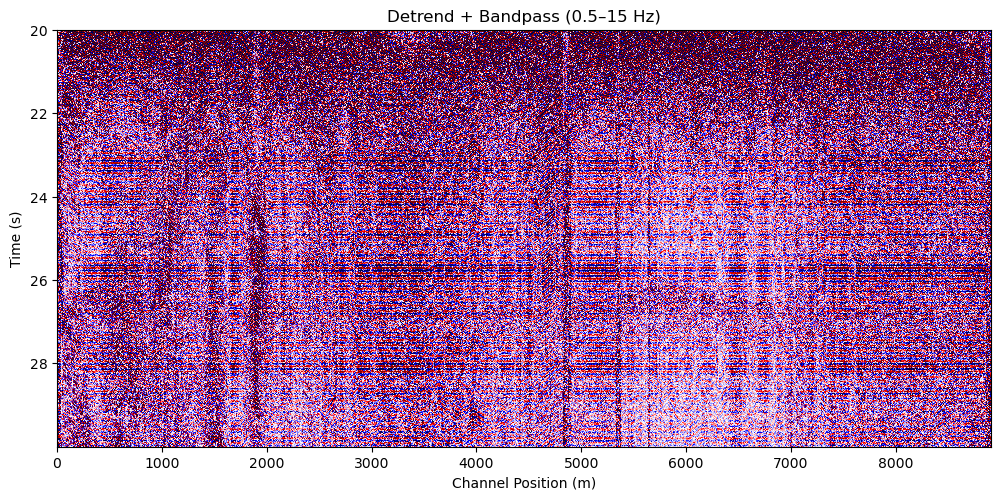

In [35]:
x_bp = detrend_then_bandpass(x, fs, f_lo=1, f_hi=30, order=5)
das.plot(20, 40, title="Detrend + Bandpass (0.5–15 Hz)", preprocess=lambda D, _: x_bp)